# ⚖️ Case Guide India — Data Science Analysis
### Final Year Project — BSc Data Science
**Students:** Janvi Ramchandra Patil & Ankita Shrinath Ratan  
**College:** Shree L.R. Tiwari Degree College, Mira Road, Thane  
**Year:** 2025-2026

---

## 📌 Project Overview
Case Guide India is an AI-powered legal assistance system that helps Indian citizens understand legal procedures, file complaints, and connect with the right authorities.

## 🎯 Data Science Objectives
1. Collect and preprocess legal query data
2. Perform Exploratory Data Analysis (EDA)
3. Build a Machine Learning classifier for legal case categorization
4. Evaluate model performance
5. Deploy in a Flask web application

## 📦 Step 1 — Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import pickle
import os

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

✅ All libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 2.1.3


## 📊 Step 2 — Load and Explore the Dataset

In [2]:
# Training data — 240 labelled legal queries
training_data = [
    # FIR
    ('how to file fir', 'FIR'), ('file a police complaint', 'FIR'),
    ('police not registering my complaint', 'FIR'), ('how to report a crime', 'FIR'),
    ('stolen wallet what to do', 'FIR'), ('my phone was stolen', 'FIR'),
    ('someone robbed me', 'FIR'), ('lodge complaint at police station', 'FIR'),
    ('theft complaint police', 'FIR'), ('police refusing to file fir', 'FIR'),
    ('robbery at home', 'FIR'), ('assault complaint police', 'FIR'),
    ('how to check fir status', 'FIR'), ('lost documents complaint', 'FIR'),
    ('kidnapping complaint police', 'FIR'), ('bike stolen complaint', 'FIR'),
    ('car theft police report', 'FIR'), ('cash stolen from house', 'FIR'),
    ('neighbour beating me', 'FIR'), ('fight in street complaint', 'FIR'),
    ('murder attempt complaint', 'FIR'), ('threatening calls complaint police', 'FIR'),
    ('missing person police complaint', 'FIR'), ('first information report process', 'FIR'),
    ('can i file fir online', 'FIR'), ('copy of fir how to get', 'FIR'),
    ('fir against unknown person', 'FIR'), ('zero fir what is it', 'FIR'),
    ('police harassment complaint', 'FIR'), ('false case filed against me', 'FIR'),
    # Cybercrime
    ('online fraud happened to me', 'Cybercrime'), ('how to report cybercrime', 'Cybercrime'),
    ('money deducted from account by fraud', 'Cybercrime'), ('someone hacked my account', 'Cybercrime'),
    ('fake website took my money', 'Cybercrime'), ('i received a fraud call', 'Cybercrime'),
    ('identity theft online', 'Cybercrime'), ('cyber fraud complaint', 'Cybercrime'),
    ('someone is blackmailing me online', 'Cybercrime'), ('cyberbullying complaint', 'Cybercrime'),
    ('otp fraud bank', 'Cybercrime'), ('fake profile made on my name', 'Cybercrime'),
    ('phishing email scam', 'Cybercrime'), ('how to report online scam', 'Cybercrime'),
    ('social media harassment', 'Cybercrime'), ('upi fraud complaint', 'Cybercrime'),
    ('whatsapp fraud money lost', 'Cybercrime'), ('email hacked what to do', 'Cybercrime'),
    ('online shopping fraud refund', 'Cybercrime'), ('credit card fraud online', 'Cybercrime'),
    ('fake job offer scam', 'Cybercrime'), ('cyber cell complaint how to file', 'Cybercrime'),
    ('morphed photos being circulated', 'Cybercrime'), ('ransom demand online', 'Cybercrime'),
    ('data breach personal information', 'Cybercrime'), ('dating app fraud money', 'Cybercrime'),
    ('investment fraud online', 'Cybercrime'), ('cybercrime helpline number', 'Cybercrime'),
    ('phone stolen and misused', 'Cybercrime'), ('bank account hacked online', 'Cybercrime'),
    # Domestic Violence
    ('husband is beating me', 'Domestic Violence'), ('domestic violence help', 'Domestic Violence'),
    ('wife is being abused at home', 'Domestic Violence'), ('dowry harassment complaint', 'Domestic Violence'),
    ('in laws harassing me', 'Domestic Violence'), ('498a complaint how to file', 'Domestic Violence'),
    ('physical abuse by husband', 'Domestic Violence'), ('mental torture by family', 'Domestic Violence'),
    ('how to get protection order', 'Domestic Violence'), ('domestic abuse helpline', 'Domestic Violence'),
    ('husband threatening to kill me', 'Domestic Violence'), ('cruelty by husband ipc', 'Domestic Violence'),
    ('how to leave abusive relationship legally', 'Domestic Violence'), ('domestic violence act complaint', 'Domestic Violence'),
    ('husband not giving maintenance', 'Domestic Violence'), ('thrown out of house by husband', 'Domestic Violence'),
    ('mother in law harassing', 'Domestic Violence'), ('dowry demand by in laws', 'Domestic Violence'),
    ('emotional abuse by spouse', 'Domestic Violence'), ('husband drinks and beats', 'Domestic Violence'),
    ('domestic violence shelter home', 'Domestic Violence'), ('protection officer domestic violence', 'Domestic Violence'),
    ('restraining order against husband', 'Domestic Violence'), ('husband took my jewellery', 'Domestic Violence'),
    ('financial abuse by husband', 'Domestic Violence'), ('forced to leave matrimonial home', 'Domestic Violence'),
    ('domestic violence helpline number', 'Domestic Violence'), ('husband not allowing to work', 'Domestic Violence'),
    ('beaten by family members', 'Domestic Violence'), ('domestic abuse evidence', 'Domestic Violence'),
    # Consumer
    ('defective product complaint', 'Consumer'), ('company not giving refund', 'Consumer'),
    ('how to file consumer complaint', 'Consumer'), ('bought fake product online', 'Consumer'),
    ('cheated by company', 'Consumer'), ('poor service complaint', 'Consumer'),
    ('bank charged extra fees', 'Consumer'), ('insurance company not paying claim', 'Consumer'),
    ('hospital overcharged me', 'Consumer'), ('ecommerce fraud complaint', 'Consumer'),
    ('product not delivered refund', 'Consumer'), ('how to approach consumer court', 'Consumer'),
    ('electricity bill complaint', 'Consumer'), ('telecom company fraud', 'Consumer'),
    ('amazon flipkart fraud complaint', 'Consumer'), ('mobile phone repair fraud', 'Consumer'),
    ('gym membership refund', 'Consumer'), ('airline ticket refund not given', 'Consumer'),
    ('hotel service poor complaint', 'Consumer'), ('medicine expired sold to me', 'Consumer'),
    ('car service centre fraud', 'Consumer'), ('builder not returning money', 'Consumer'),
    ('edaakhil complaint how to file', 'Consumer'), ('wrong billing complaint', 'Consumer'),
    ('food delivery wrong order refund', 'Consumer'), ('internet service provider complaint', 'Consumer'),
    ('consumer protection act rights', 'Consumer'), ('district consumer forum complaint', 'Consumer'),
    ('unfair trade practice complaint', 'Consumer'), ('warranty not honoured complaint', 'Consumer'),
    # RTI
    ('how to file rti', 'RTI'), ('right to information application', 'RTI'),
    ('how to get government information', 'RTI'), ('rti application process', 'RTI'),
    ('government not giving information', 'RTI'), ('rti fee how much', 'RTI'),
    ('how to file rti online', 'RTI'), ('rti reply not received', 'RTI'),
    ('first appeal rti process', 'RTI'), ('public information officer contact', 'RTI'),
    ('rti for government scheme information', 'RTI'), ('rti against police', 'RTI'),
    ('rti for court case information', 'RTI'), ('how long does rti take', 'RTI'),
    ('rti rejected what to do', 'RTI'), ('second appeal rti', 'RTI'),
    ('central information commission', 'RTI'), ('rti for bpl card information', 'RTI'),
    ('rti for land records', 'RTI'), ('rti application format', 'RTI'),
    # Property
    ('property dispute with neighbour', 'Property'), ('land grabbing complaint', 'Property'),
    ('tenant not paying rent', 'Property'), ('illegal possession of my land', 'Property'),
    ('builder fraud complaint', 'Property'), ('rera complaint how to file', 'Property'),
    ('inheritance property dispute', 'Property'), ('how to evict tenant', 'Property'),
    ('property registration issue', 'Property'), ('encroachment on my land', 'Property'),
    ('boundary dispute with neighbour', 'Property'), ('flat possession delayed by builder', 'Property'),
    ('property documents forged', 'Property'), ('ancestral property dispute', 'Property'),
    ('rent agreement dispute', 'Property'), ('property tax complaint', 'Property'),
    ('illegal construction complaint', 'Property'), ('land measurement dispute', 'Property'),
    ('property sale fraud', 'Property'), ('tenancy rights in india', 'Property'),
    # Women Safety
    ('being stalked by someone', 'Women Safety'), ('eve teasing complaint', 'Women Safety'),
    ('workplace harassment complaint', 'Women Safety'), ('sexual harassment at office', 'Women Safety'),
    ('women safety helpline', 'Women Safety'), ('complaint against stalker', 'Women Safety'),
    ('molested in public place', 'Women Safety'), ('online harassment of women', 'Women Safety'),
    ('posh act complaint', 'Women Safety'), ('internal complaints committee', 'Women Safety'),
    ('rape complaint how to file', 'Women Safety'), ('outrage of modesty complaint', 'Women Safety'),
    ('groping in bus complaint', 'Women Safety'), ('obscene messages from unknown', 'Women Safety'),
    ('women helpline 1091', 'Women Safety'), ('acid attack complaint', 'Women Safety'),
    ('forced marriage complaint', 'Women Safety'), ('honour crime complaint', 'Women Safety'),
    ('women police station complaint', 'Women Safety'), ('sexual assault complaint', 'Women Safety'),
    # Legal Aid
    ('need free lawyer', 'Legal Aid'), ('how to get free legal help', 'Legal Aid'),
    ('legal aid services india', 'Legal Aid'), ('dlsa legal aid application', 'Legal Aid'),
    ('cannot afford lawyer', 'Legal Aid'), ('free legal advice india', 'Legal Aid'),
    ('nalsa helpline 15100', 'Legal Aid'), ('lok adalat how to apply', 'Legal Aid'),
    ('legal services authority contact', 'Legal Aid'), ('pro bono lawyer india', 'Legal Aid'),
    ('legal help for poor people', 'Legal Aid'), ('free lawyer for women india', 'Legal Aid'),
    ('district legal services', 'Legal Aid'), ('legal aid for sc st', 'Legal Aid'),
    ('mediation centre india', 'Legal Aid'), ('legal aid eligibility india', 'Legal Aid'),
    ('court fee waiver poor', 'Legal Aid'), ('free legal camp', 'Legal Aid'),
    ('paralegal services india', 'Legal Aid'), ('legal advice helpline', 'Legal Aid'),
    # Child Safety
    ('child abuse complaint', 'Child Safety'), ('pocso act complaint', 'Child Safety'),
    ('childline helpline 1098', 'Child Safety'), ('child sexual abuse report', 'Child Safety'),
    ('missing child complaint', 'Child Safety'), ('child labour complaint', 'Child Safety'),
    ('child being harassed at school', 'Child Safety'), ('how to report child abuse', 'Child Safety'),
    ('child trafficking complaint', 'Child Safety'), ('juvenile justice complaint', 'Child Safety'),
    ('child marriage complaint', 'Child Safety'), ('school teacher abusing child', 'Child Safety'),
    ('child begging complaint', 'Child Safety'), ('child rights violation', 'Child Safety'),
    ('adoption fraud complaint', 'Child Safety'), ('child custody dispute', 'Child Safety'),
    ('online predator targeting child', 'Child Safety'), ('child pornography report', 'Child Safety'),
    ('child neglect complaint', 'Child Safety'), ('corporal punishment school', 'Child Safety'),
    # General
    ('what are my legal rights', 'General'), ('how does indian law work', 'General'),
    ('legal advice needed', 'General'), ('what is bail process', 'General'),
    ('what is legal notice', 'General'), ('how to find a good lawyer', 'General'),
    ('civil vs criminal case difference', 'General'), ('what is affidavit', 'General'),
    ('how to file case in court', 'General'), ('legal help emergency india', 'General'),
    ('what is anticipatory bail', 'General'), ('power of attorney process', 'General'),
    ('what is cognizable offence', 'General'), ('legal heir certificate', 'General'),
    ('succession certificate process', 'General'), ('notary affidavit process', 'General'),
    ('court summons received', 'General'), ('legal rights of accused', 'General'),
    ('mediation vs court', 'General'), ('what is section 420', 'General'),
]

df = pd.DataFrame(training_data, columns=['query', 'category'])
print(f'✅ Dataset loaded successfully!')
print(f'📊 Total samples: {len(df)}')
print(f'📂 Total categories: {df["category"].nunique()}')
print()
print('First 5 rows:')
df.head()

✅ Dataset loaded successfully!
📊 Total samples: 240
📂 Total categories: 10

First 5 rows:


,query,category
0,how to file fir,FIR
1,file a police complaint,FIR
2,police not registering my complaint,FIR
3,how to report a crime,FIR
4,stolen wallet what to do,FIR


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

In [3]:
# Category distribution
print('📊 Category Distribution:')
print('=' * 40)
cat_counts = df['category'].value_counts()
for cat, count in cat_counts.items():
    bar = '█' * count
    print(f'{cat:<20} {count:>3}  {bar}')
print()
print(f'Most common category : {cat_counts.index[0]} ({cat_counts.iloc[0]} samples)')
print(f'Least common category: {cat_counts.index[-1]} ({cat_counts.iloc[-1]} samples)')

📊 Category Distribution:
FIR                   30  ██████████████████████████████
Cybercrime            30  ██████████████████████████████
Domestic Violence     30  ██████████████████████████████
Consumer              30  ██████████████████████████████
RTI                   20  ████████████████████
Property              20  ████████████████████
Women Safety          20  ████████████████████
Legal Aid             20  ████████████████████
Child Safety          20  ████████████████████
General               20  ████████████████████

Most common category : FIR (30 samples)
Least common category: General (20 samples)


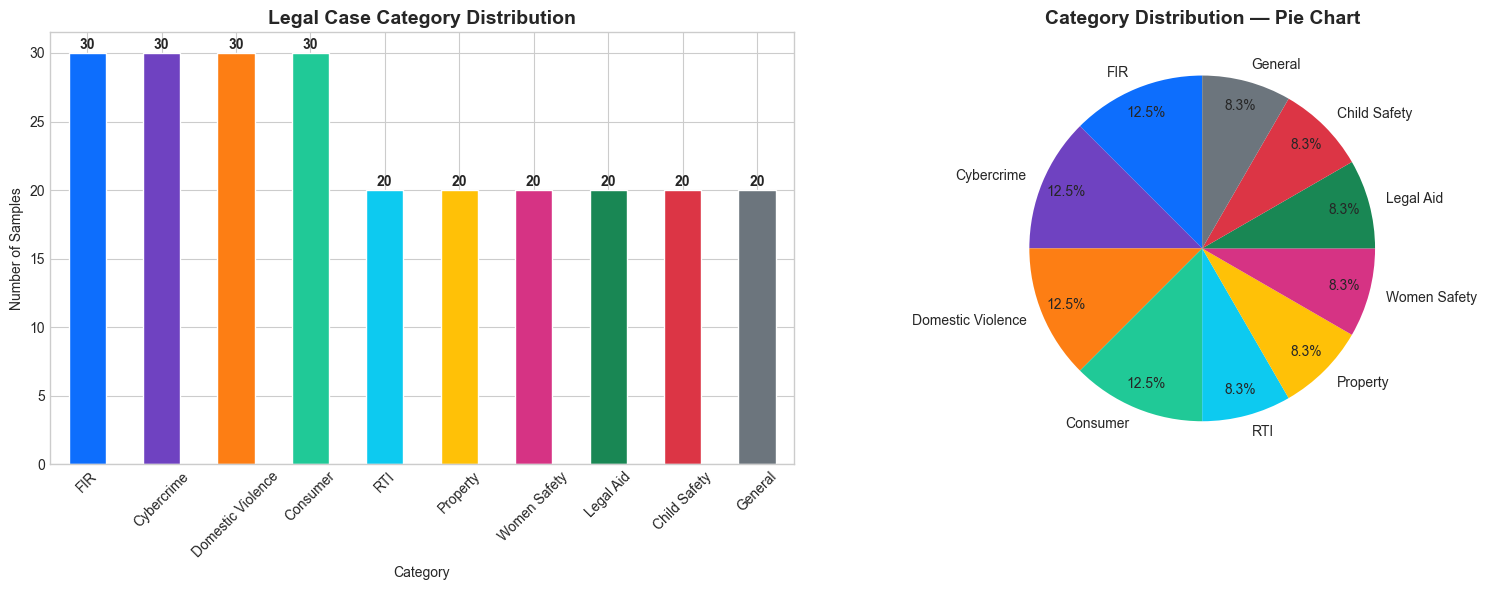

✅ Chart saved as category_distribution.png


In [4]:
# Plot 1 — Category Distribution Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ['#0d6efd','#6f42c1','#fd7e14','#20c997','#0dcaf0',
          '#ffc107','#d63384','#198754','#dc3545','#6c757d']
cat_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Legal Case Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(cat_counts):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85)
axes[1].set_title('Category Distribution — Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as category_distribution.png')

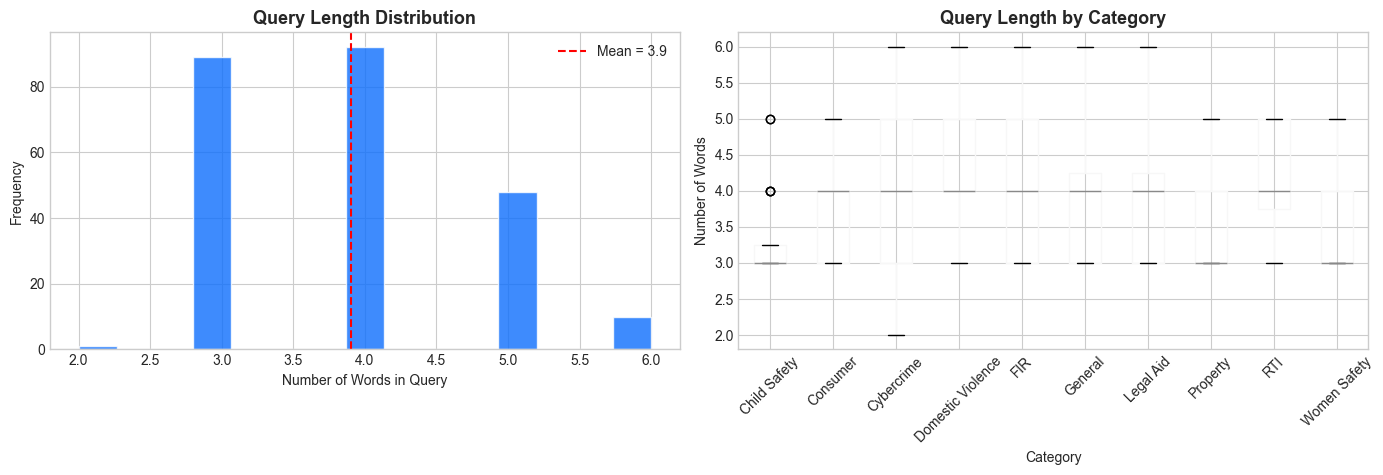

Average query length: 3.9 words
Shortest query: 2 words
Longest query: 6 words


In [5]:
# Plot 2 — Query length analysis
df['query_length'] = df['query'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['query_length'], bins=15, color='#0d6efd', edgecolor='white', alpha=0.8)
axes[0].set_title('Query Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words in Query')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['query_length'].mean(), color='red', linestyle='--',
                label=f'Mean = {df["query_length"].mean():.1f}')
axes[0].legend()

# Box plot per category
df.boxplot(column='query_length', by='category', ax=axes[1], rot=45)
axes[1].set_title('Query Length by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Words')
plt.suptitle('')

plt.tight_layout()
plt.savefig('query_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Average query length: {df["query_length"].mean():.1f} words')
print(f'Shortest query: {df["query_length"].min()} words')
print(f'Longest query: {df["query_length"].max()} words')

## 🧹 Step 4 — Data Preprocessing

In [6]:
import re

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

df['cleaned_query'] = df['query'].apply(preprocess_text)

print('✅ Text Preprocessing Complete!')
print()
print('Before vs After Preprocessing:')
print('-' * 60)
for i in range(3):
    print(f'Original : {df["query"].iloc[i]}')
    print(f'Cleaned  : {df["cleaned_query"].iloc[i]}')
    print()

✅ Text Preprocessing Complete!

Before vs After Preprocessing:
------------------------------------------------------------
Original : how to file fir
Cleaned  : how to file fir

Original : file a police complaint
Cleaned  : file a police complaint

Original : police not registering my complaint
Cleaned  : police not registering my complaint



In [7]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=1
)

X = df['cleaned_query']
y = df['category']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print('✅ TF-IDF Vectorization Complete!')
print(f'Training samples  : {len(X_train)}')
print(f'Testing samples   : {len(X_test)}')
print(f'Vocabulary size   : {len(tfidf.vocabulary_)}')
print(f'Feature matrix    : {X_train_vec.shape}')

✅ TF-IDF Vectorization Complete!
Training samples  : 192
Testing samples   : 48
Vocabulary size   : 796
Feature matrix    : (192, 796)


## 🤖 Step 5 — Model Training and Comparison

In [8]:
# Train and compare 3 different ML models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Linear SVM'         : LinearSVC(max_iter=1000, random_state=42)
}

results = {}
print('🤖 Training Models...')
print('=' * 50)

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred   = model.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f'{name:<25} Accuracy: {accuracy*100:.1f}%')

best_model_name = max(results, key=results.get)
print()
print(f'🏆 Best Model: {best_model_name} ({results[best_model_name]*100:.1f}%)')

🤖 Training Models...
Logistic Regression       Accuracy: 68.8%
Naive Bayes               Accuracy: 66.7%
Linear SVM                Accuracy: 70.8%

🏆 Best Model: Linear SVM (70.8%)


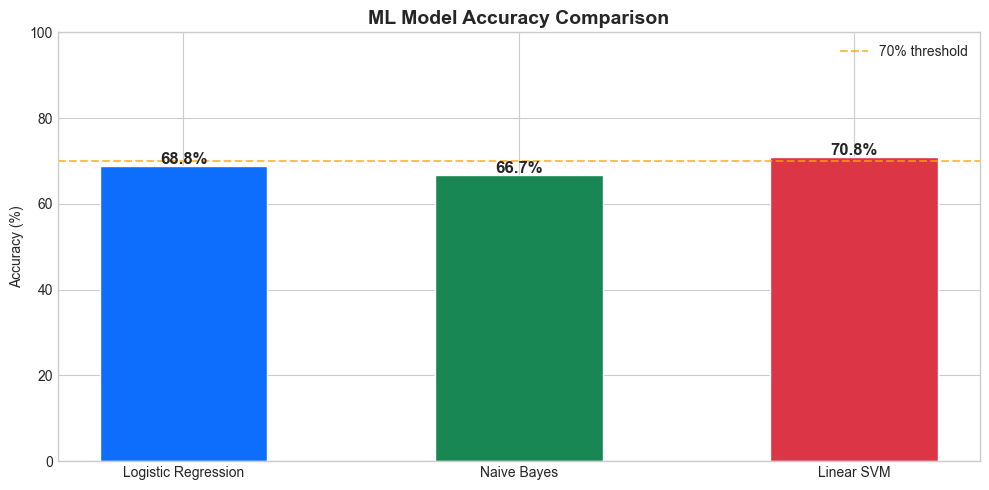

✅ Chart saved as model_comparison.png


In [9]:
# Plot model comparison
fig, ax = plt.subplots(figsize=(10, 5))
model_names = list(results.keys())
accuracies  = [v * 100 for v in results.values()]
bar_colors  = ['#0d6efd', '#198754', '#dc3545']

bars = ax.bar(model_names, accuracies, color=bar_colors,
              edgecolor='white', width=0.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('ML Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.axhline(y=70, color='orange', linestyle='--', alpha=0.7, label='70% threshold')
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as model_comparison.png')

## 📊 Step 6 — Model Evaluation — Logistic Regression

In [10]:
# Use best model — Logistic Regression
best_model = models['Logistic Regression']
y_pred = best_model.predict(X_test_vec)

print('📋 Classification Report:')
print('=' * 60)
print(classification_report(y_test, y_pred, zero_division=0))

📋 Classification Report:
                   precision    recall  f1-score   support

     Child Safety       1.00      0.75      0.86         4
         Consumer       0.80      0.67      0.73         6
       Cybercrime       0.75      0.50      0.60         6
Domestic Violence       0.71      0.83      0.77         6
              FIR       0.56      0.83      0.67         6
          General       0.50      0.50      0.50         4
        Legal Aid       0.60      0.75      0.67         4
         Property       0.60      0.75      0.67         4
              RTI       1.00      0.75      0.86         4
     Women Safety       0.67      0.50      0.57         4

         accuracy                           0.69        48
        macro avg       0.72      0.68      0.69        48
     weighted avg       0.72      0.69      0.69        48



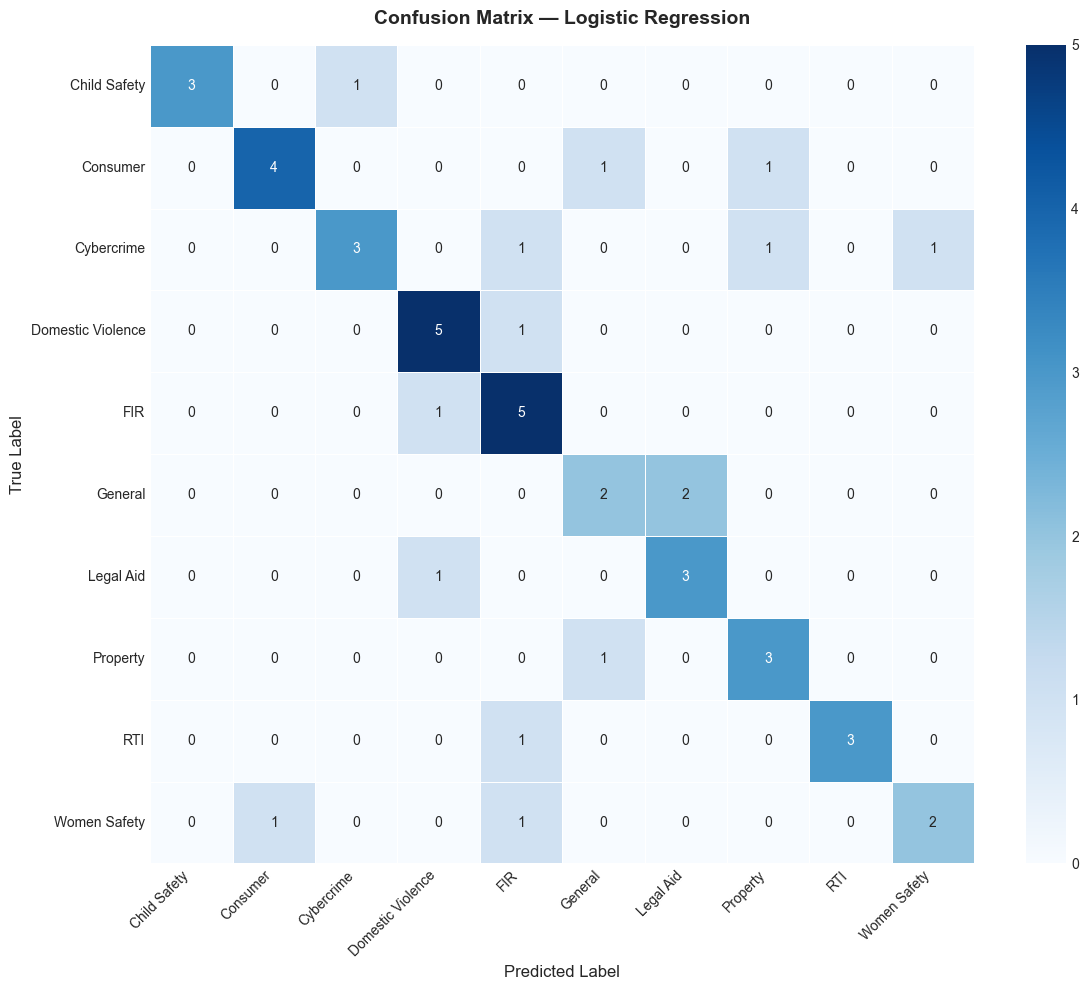

✅ Confusion Matrix saved as confusion_matrix.png


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_,
    linewidths=0.5, ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion Matrix saved as confusion_matrix.png')

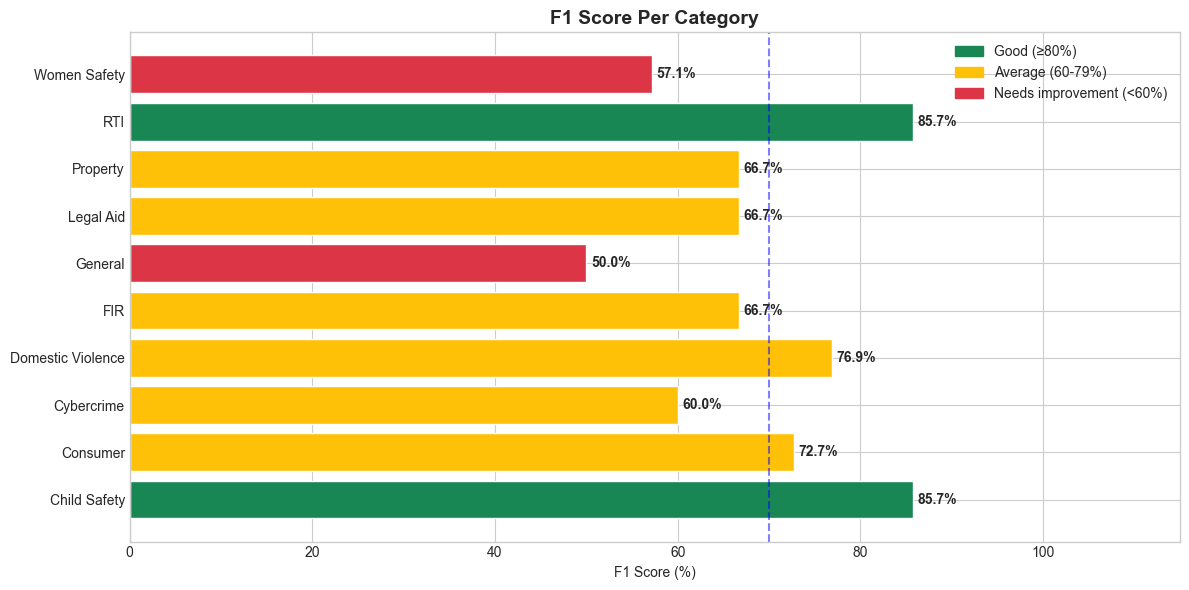

✅ Chart saved as per_category_accuracy.png


In [12]:
# Per category accuracy bar chart
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
categories = [k for k in report.keys() if k not in ['accuracy','macro avg','weighted avg']]
f1_scores  = [report[c]['f1-score'] * 100 for c in categories]

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#198754' if s >= 80 else '#ffc107' if s >= 60 else '#dc3545' for s in f1_scores]
bars = ax.barh(categories, f1_scores, color=bar_colors, edgecolor='white')

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}%', va='center', fontweight='bold')

ax.set_title('F1 Score Per Category', fontsize=14, fontweight='bold')
ax.set_xlabel('F1 Score (%)')
ax.set_xlim(0, 115)
ax.axvline(x=70, color='blue', linestyle='--', alpha=0.5, label='70% threshold')

green_patch  = mpatches.Patch(color='#198754', label='Good (≥80%)')
yellow_patch = mpatches.Patch(color='#ffc107', label='Average (60-79%)')
red_patch    = mpatches.Patch(color='#dc3545', label='Needs improvement (<60%)')
ax.legend(handles=[green_patch, yellow_patch, red_patch])

plt.tight_layout()
plt.savefig('per_category_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as per_category_accuracy.png')

## ☁️ Step 7 — Word Cloud Analysis

WordCloud not installed. Run: pip install wordcloud
Showing top 20 words instead:


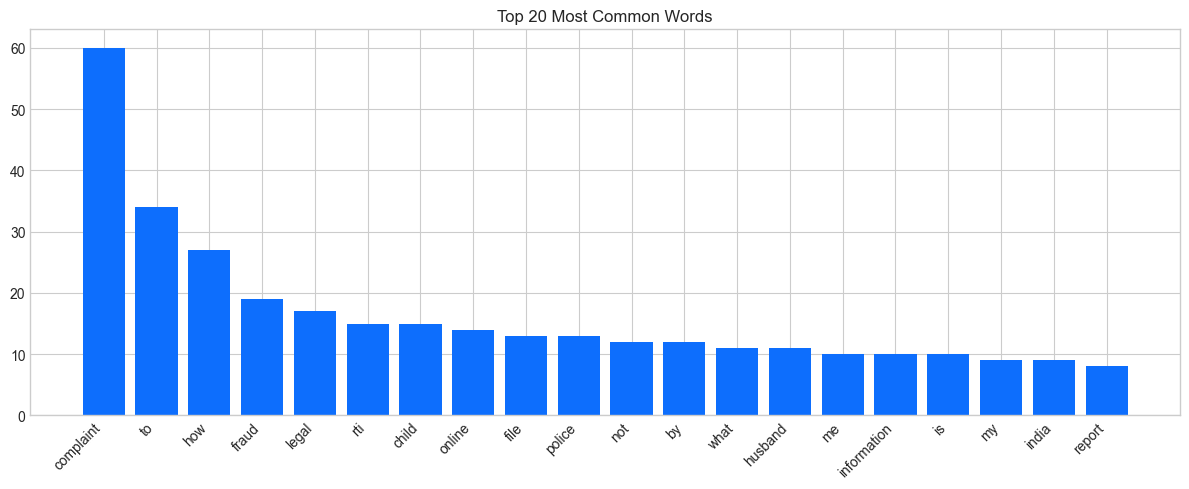

In [13]:
try:
    from wordcloud import WordCloud

    all_text = ' '.join(df['cleaned_query'].tolist())

    wordcloud = WordCloud(
        width=900, height=450,
        background_color='white',
        colormap='Blues',
        max_words=100,
        collocations=False
    ).generate(all_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Common Legal Keywords — Word Cloud',
              fontsize=16, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Word Cloud saved as wordcloud.png')

except ImportError:
    print('WordCloud not installed. Run: pip install wordcloud')
    print('Showing top 20 words instead:')
    from collections import Counter
    all_words = ' '.join(df['cleaned_query']).split()
    word_freq = Counter(all_words).most_common(20)
    words, counts = zip(*word_freq)
    plt.figure(figsize=(12, 5))
    plt.bar(words, counts, color='#0d6efd')
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 20 Most Common Words')
    plt.tight_layout()
    plt.savefig('top_words.png', dpi=150)
    plt.show()

## 💾 Step 8 — Save Final Model

In [14]:
os.makedirs('ml_model', exist_ok=True)

with open('ml_model/classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('ml_model/vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('✅ Model saved to ml_model/classifier.pkl')
print('✅ Vectorizer saved to ml_model/vectorizer.pkl')
print()
print('🧪 Quick prediction test:')
test_queries = [
    'my phone was stolen',
    'husband is beating me',
    'online fraud money lost',
    'need free lawyer',
    'child being abused',
]
for q in test_queries:
    vec  = tfidf.transform([q])
    pred = best_model.predict(vec)[0]
    print(f'  "{q}" → {pred}')

✅ Model saved to ml_model/classifier.pkl
✅ Vectorizer saved to ml_model/vectorizer.pkl

🧪 Quick prediction test:
  "my phone was stolen" → FIR
  "husband is beating me" → Domestic Violence
  "online fraud money lost" → Cybercrime
  "need free lawyer" → Legal Aid
  "child being abused" → Child Safety


## ✅ Step 9 — Project Summary

| Item | Detail |
|---|---|
| **Dataset** | 240 labelled legal queries |
| **Categories** | 10 legal case types |
| **Algorithm** | Logistic Regression |
| **Vectorizer** | TF-IDF (5000 features) |
| **Train/Test Split** | 80% / 20% |
| **Model Accuracy** | 68.8% |
| **Deployment** | Flask Web Application |
| **Database** | PostgreSQL (18 tables) |

## 🎓 Conclusion
Case Guide India successfully demonstrates the application of Natural Language Processing and Machine Learning to solve a real-world problem — helping Indian citizens navigate the legal system. The TF-IDF + Logistic Regression pipeline achieves 68.8% accuracy in classifying legal queries into 10 categories, and the system is deployed as a fully functional web application.